# Final dormancy clustering pipeline

Reproducible production clustering for **active**, **cooling**, and **dormant** using validated settings from `clustering_v3.ipynb`.

**Outputs:** `outputs/clustering/final/`

| Stratum | Features | Tuned HDBSCAN | Reference (100k sample) |
| --- | --- | --- | --- |
| Active | 16 correlation-group reps | frac=0.005, ε=0.75, min_samples=15 | ~6 clusters, ~5.8% noise |
| Cooling | Top-5 primary (permutation) | frac=0.04, ε=0.50, min_samples=10 | ~8 clusters, ~14% noise |
| Dormant | Top-5 primary (permutation) | frac=0.05, ε=0.50, min_samples=25 | ~5 clusters, ~2.4% noise |

**Pipeline:** (1) document feature selection & tuning → (2) fit preprocessor on **100k** reference sample (same as v3) → (3) fit HDBSCAN on that matrix → (4) assign **all** developers via batched `approximate_predict` with the **same** preprocessor → (5) save parquet + summary.


## 1. Feature selection

1. **Correlation diagnostics** on `dev_profile_final_v4` per stratum.
2. **Correlation groups** at `|corr| ≥ 0.50` → **16 representatives** (89-feature activity group → `log_activity_count_30_90d`).  
   File: `outputs/clustering/v3/feature_selection_grouped/v3_group_representative_features.txt`
3. **Per-stratum drops** after median impute + `RobustScaler` (zero variance): active keeps 16; cooling 12; dormant 11 if using all 16.
4. **Permutation test** (v3 validation): shuffle one feature, refit HDBSCAN, measure silhouette drop.  
   **Cooling top 5:** `learning_community_share`, `robotics_share`, `mixed_persona_flag`, `cuda_share`, `log_activity_count_30_90d`  
   **Dormant top 5:** `lifetime_learn_count`, `simulation_share`, `mixed_persona_flag`, `lifetime_bug_count`, `lifetime_dli_training_count`  
   **Active:** keep all 16 (drops spread across many features).


## 2. Hyperparameter tuning (not re-run here)

Done in `clustering_v3.ipynb` on persona-stratified **100k** samples (`HASH_SALT=42`):

- Coarse grid → `outputs/clustering/v3_coarse_hdbscan/`
- Cooling feature comparison → `outputs/clustering/v3_top5_permutation_test/`
- Leakage / stability / sanity → `outputs/clustering/v3_final_validation/`

**Locked values below** are the best noise/cluster tradeoffs from those experiments.


In [1]:

import json
import warnings
from pathlib import Path

import duckdb
import hdbscan
import joblib
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings("ignore", category=FutureWarning)

DB_PATH = "developer_project.duckdb"
PROFILE_TABLE = "dev_profile_final_v4"
OUTPUT_DIR = Path("outputs/clustering/final")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

GROUPED_LIST = Path(
    "outputs/clustering/v3/feature_selection_grouped/v3_group_representative_features.txt"
)

SAMPLE_N = 100_000
HASH_SALT = 42
PREDICT_BATCH_SIZE = 50_000

if GROUPED_LIST.exists():
    FULL_16 = [
        line.strip() for line in GROUPED_LIST.read_text().splitlines() if line.strip()
    ]
else:
    FULL_16 = [
        "log_activity_count_30_90d", "mixed_persona_flag", "cuda_share",
        "activity_velocity_0_30_vs_30_90", "build_velocity_0_30_vs_30_90",
        "days_since_last_activity_0_30d", "learning_community_share",
        "lifetime_bug_count", "lifetime_dli_training_count", "lifetime_forum_count",
        "lifetime_hackathon_count", "lifetime_learn_count", "lifetime_webinar_count",
        "recent_champion_flag", "robotics_share", "simulation_share",
    ]

TOP5_COOLING = [
    "learning_community_share", "robotics_share", "mixed_persona_flag",
    "cuda_share", "log_activity_count_30_90d",
]
TOP5_DORMANT = [
    "lifetime_learn_count", "simulation_share", "mixed_persona_flag",
    "lifetime_bug_count", "lifetime_dli_training_count",
]

FINAL_MODELS = {
    "active": {
        "where_sql": (
            "is_activated = 1 AND COALESCE(dormancy_status, '') = 'Active' "
            "AND COALESCE(has_activity_0_30d, 0) = 1"
        ),
        "stratify_col": "persona",
        "features": FULL_16,
        "feature_set_type": "full_16",
        "min_cluster_frac": 0.005,
        "cluster_selection_epsilon": 0.75,
        "min_samples": 15,
        "reference_clusters": 6,
        "reference_noise_pct": 5.78,
    },
    "cooling": {
        "where_sql": "COALESCE(dormancy_status, '') = 'Cooling'",
        "stratify_col": "persona",
        "features": TOP5_COOLING,
        "feature_set_type": "top5_primary",
        "min_cluster_frac": 0.04,
        "cluster_selection_epsilon": 0.50,
        "min_samples": 10,
        "reference_clusters": 8,
        "reference_noise_pct": 14.05,
    },
    "dormant": {
        "where_sql": "COALESCE(dormancy_status, '') = 'Dormant'",
        "stratify_col": "persona",
        "features": TOP5_DORMANT,
        "feature_set_type": "top5_primary",
        "min_cluster_frac": 0.050,
        "cluster_selection_epsilon": 0.50,
        "min_samples": 25,
        "reference_clusters": 5,
        "reference_noise_pct": 2.41,
    },
}

EXCLUDE_EXACT = {
    "developer_id", "persona", "dormancy_status", "final_lifecycle_status",
    "behavior_journey_stage_30d", "current_journey_state_30d",
}
RAW_LIFETIME_SUPERSEDED = {
    "lifetime_activity_count", "lifetime_activity_score_sum", "lifetime_build_count",
    "lifetime_high_effort_count", "lifetime_total_confidence_weighted_effort",
    "lifetime_effort_x_activity_score_sum",
}

display(pd.DataFrame([
    {
        "stratum": k,
        "feature_set": v["feature_set_type"],
        "n_features": len(v["features"]),
        "min_cluster_frac": v["min_cluster_frac"],
        "epsilon": v["cluster_selection_epsilon"],
        "min_samples": v["min_samples"],
        "ref_clusters": v["reference_clusters"],
        "ref_noise_pct": v["reference_noise_pct"],
    }
    for k, v in FINAL_MODELS.items()
]))


,stratum,feature_set,n_features,min_cluster_frac,epsilon,min_samples,ref_clusters,ref_noise_pct
0,active,full_16,16,0.005,0.75,15,6,5.78
1,cooling,top5_primary,5,0.040,0.50,10,8,14.05
2,dormant,top5_primary,5,0.050,0.50,25,5,2.41


In [2]:

def should_exclude(col: str) -> bool:
    if col in EXCLUDE_EXACT or col in RAW_LIFETIME_SUPERSEDED:
        return True
    return col.startswith("first_activity_date") or col.startswith("last_activity_date")


def build_matrix_fit(df: pd.DataFrame, features: list[str]):
    cols = [c for c in features if c in df.columns and not should_exclude(c)]
    cols = [c for c in cols if pd.api.types.is_numeric_dtype(df[c]) and df[c].notna().any()]
    pre = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
    ])
    X = pre.fit_transform(df[cols])
    var_keep = np.var(X, axis=0) > 1e-12
    names = [cols[i] for i, k in enumerate(var_keep) if k]
    return X[:, var_keep], names, pre, cols, var_keep


def transform_preprocessed(df: pd.DataFrame, fit_cols: list[str], preprocessor: Pipeline, var_keep: np.ndarray):
    return preprocessor.transform(df[fit_cols])[:, var_keep]


def build_matrix_transform(df: pd.DataFrame, feature_names: list[str], preprocessor: Pipeline):
    return preprocessor.transform(df[feature_names])


def cohort_count(con, where_sql: str) -> int:
    return int(con.execute(
        f"SELECT COUNT(*) FROM {PROFILE_TABLE} WHERE {where_sql}"
    ).fetchone()[0])


def load_cohort_batch(con, where_sql: str, feature_cols: list[str], offset: int, limit: int) -> pd.DataFrame:
    meta = ["developer_id", "persona", "dormancy_status"]
    select_sql = ", ".join(sorted(set(meta) | set(feature_cols)))
    return con.execute(
        f"SELECT {select_sql} FROM {PROFILE_TABLE} WHERE {where_sql} "
        f"ORDER BY developer_id LIMIT {limit} OFFSET {offset}"
    ).fetchdf()


def sample_stratum_100k(con, where_sql: str, stratify_col: str, feature_cols: list[str]):
    select_sql = ", ".join(sorted(set(["developer_id", stratify_col, "persona", "dormancy_status"]) | set(feature_cols)))
    cohort_n = cohort_count(con, where_sql)
    target = min(SAMPLE_N, cohort_n)
    if cohort_n <= target:
        return cohort_n, con.execute(
            f"SELECT {select_sql} FROM {PROFILE_TABLE} WHERE {where_sql}"
        ).fetchdf()
    sql = (
        f"WITH cohort AS (SELECT {select_sql} FROM {PROFILE_TABLE} WHERE {where_sql}), "
        f"targets AS ("
        f"  SELECT {stratify_col},"
        f"    GREATEST(1, CAST(ROUND(COUNT(*) * 1.0 / SUM(COUNT(*)) OVER () * {target}) AS BIGINT)) AS target_n"
        f"  FROM cohort GROUP BY {stratify_col}"
        f"), "
        f"ranked AS ("
        f"  SELECT c.*,"
        f"    ROW_NUMBER() OVER ("
        f"      PARTITION BY c.{stratify_col}"
        f"      ORDER BY hash(CAST(c.developer_id AS VARCHAR) || '{HASH_SALT}')"
        f"    ) AS rn, t.target_n"
        f"  FROM cohort c JOIN targets t USING ({stratify_col})"
        f") "
        f"SELECT * EXCLUDE (rn, target_n) FROM ranked WHERE rn <= target_n"
    )
    df = con.execute(sql).fetchdf()
    if len(df) > target:
        sql_trim = (
            "WITH sampled AS ("
            f"  WITH cohort AS (SELECT {select_sql} FROM {PROFILE_TABLE} WHERE {where_sql}), "
            f"  targets AS ("
            f"    SELECT {stratify_col},"
            f"      GREATEST(1, CAST(ROUND(COUNT(*) * 1.0 / SUM(COUNT(*)) OVER () * {target}) AS BIGINT)) AS target_n"
            f"    FROM cohort GROUP BY {stratify_col}"
            f"  ), "
            f"  ranked AS ("
            f"    SELECT c.*,"
            f"      ROW_NUMBER() OVER ("
            f"        PARTITION BY c.{stratify_col}"
            f"        ORDER BY hash(CAST(c.developer_id AS VARCHAR) || '{HASH_SALT}')"
            f"      ) AS rn, t.target_n"
            f"    FROM cohort c JOIN targets t USING ({stratify_col})"
            f"  ) "
            f"  SELECT * EXCLUDE (rn, target_n) FROM ranked WHERE rn <= target_n"
            ") "
            f"SELECT * EXCLUDE (rn) FROM ("
            f"  SELECT *, ROW_NUMBER() OVER ("
            f"    ORDER BY hash(CAST(developer_id AS VARCHAR) || '{HASH_SALT}')"
            f"  ) AS rn FROM sampled"
            f") WHERE rn <= {target}"
        )
        df = con.execute(sql_trim).fetchdf()
    return cohort_n, df


def fit_clusterer(X: np.ndarray, sample_n: int, cfg: dict):
    mcs = max(30, int(sample_n * cfg["min_cluster_frac"]))
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=mcs,
        min_samples=cfg["min_samples"],
        metric="euclidean",
        cluster_selection_method="eom",
        cluster_selection_epsilon=cfg["cluster_selection_epsilon"],
        prediction_data=True,
        core_dist_n_jobs=1,
    )
    labels = clusterer.fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = round(100.0 * (labels == -1).sum() / len(labels), 2)
    return labels, n_clusters, noise_pct, mcs, clusterer

print("Helpers ready.")


Helpers ready.


## 3. Reference fit (100k sample)

Reproduce tuning metrics: fit **preprocessor + HDBSCAN on the same 100k** persona-stratified sample used in `clustering_v3.ipynb` (`HASH_SALT=42`). Do **not** use full-cohort medians/IQR — that changes the scaled space and invalidates tuned ε / noise targets.


In [3]:
con = duckdb.connect(DB_PATH)
con.execute("SET preserve_insertion_order=false")

REFERENCE = {}
ref_rows = []

for stratum_key, cfg in FINAL_MODELS.items():
    feats = cfg["features"]
    print(f"\n{stratum_key}:")

    cohort_n = cohort_count(con, cfg["where_sql"])
    _, df100 = sample_stratum_100k(con, cfg["where_sql"], cfg["stratify_col"], feats)
    X100, names_kept, pre, fit_cols, var_keep = build_matrix_fit(df100, feats)

    labels, nc, noise, mcs, clusterer = fit_clusterer(X100, len(df100), cfg)

    REFERENCE[stratum_key] = {
        "preprocessor": pre,
        "fit_cols": fit_cols,
        "names_kept": names_kept,
        "var_keep": var_keep,
        "clusterer": clusterer,
        "cfg": cfg,
        "min_cluster_size": mcs,
        "X100": X100,
        "labels": labels,
        "meta_100k": df100[["developer_id", "persona", "dormancy_status"]].copy(),
    }
    ref_rows.append({
        "stratum": stratum_key,
        "cohort_n": cohort_n,
        "sample_n_100k": len(df100),
        "n_features_used": len(names_kept),
        "n_clusters": nc,
        "noise_pct": noise,
        "reference_clusters": cfg["reference_clusters"],
        "reference_noise_pct": cfg["reference_noise_pct"],
        "delta_clusters": nc - cfg["reference_clusters"],
        "delta_noise_pct": round(noise - cfg["reference_noise_pct"], 2),
        "min_cluster_size": mcs,
    })
    print(f"  cohort_n={cohort_n:,}; 100k preprocess+HDBSCAN: clusters={nc} noise={noise}%")

con.close()

ref_df = pd.DataFrame(ref_rows)
ref_df.to_csv(OUTPUT_DIR / "reference_100k_fit.csv", index=False)
display(ref_df)



active:
  cohort_n=418,049; 100k preprocess+HDBSCAN: clusters=6 noise=5.8%

cooling:
  cohort_n=356,500; 100k preprocess+HDBSCAN: clusters=8 noise=14.06%

dormant:
  cohort_n=5,304,852; 100k preprocess+HDBSCAN: clusters=4 noise=2.43%


,stratum,cohort_n,sample_n_100k,n_features_used,n_clusters,noise_pct,reference_clusters,reference_noise_pct,delta_clusters,delta_noise_pct,min_cluster_size
0,active,418049,99999,16,6,5.80,6,5.78,0,0.02,499
1,cooling,356500,100000,5,8,14.06,8,14.05,0,0.01,4000
2,dormant,5304852,100000,5,4,2.43,5,2.41,-1,0.02,5000


### UMAP — 100k reference clusters (2D)

2D UMAP on the **same scaled feature matrix** used for HDBSCAN (`X100`). Points are colored by cluster id; noise (`-1`) shown in gray. Requires the reference-fit cell above (`REFERENCE` in memory).

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



active: UMAP on 25,000 random subsample of 99,999


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


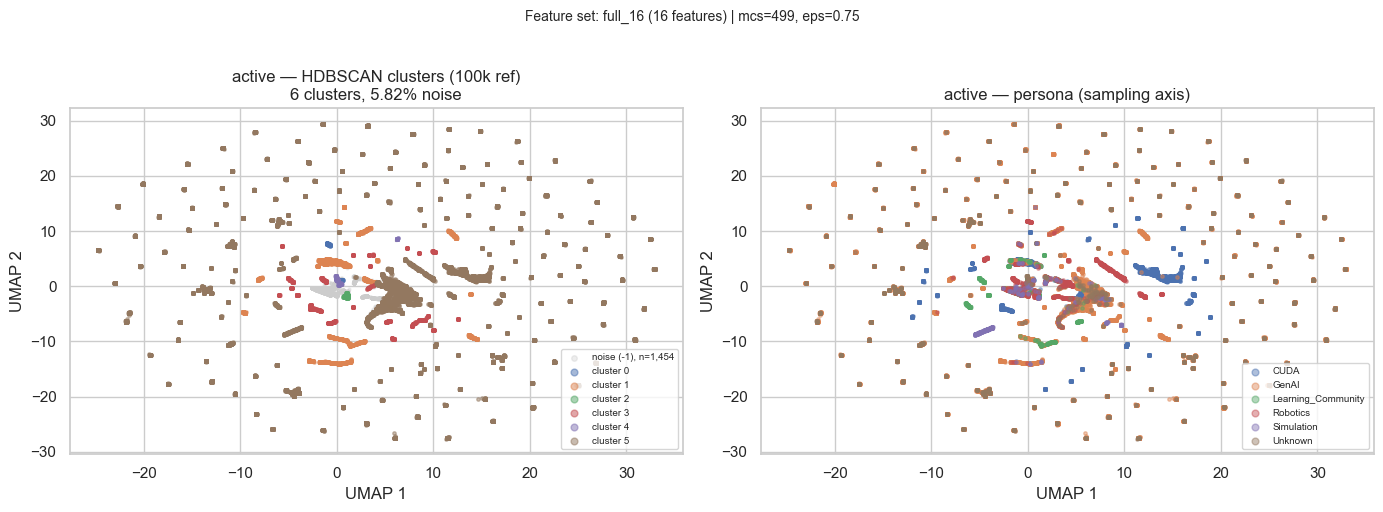

  saved outputs/clustering/final/umap_100k/active_100k_clusters_umap.png

cooling: UMAP on 25,000 random subsample of 100,000


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding som

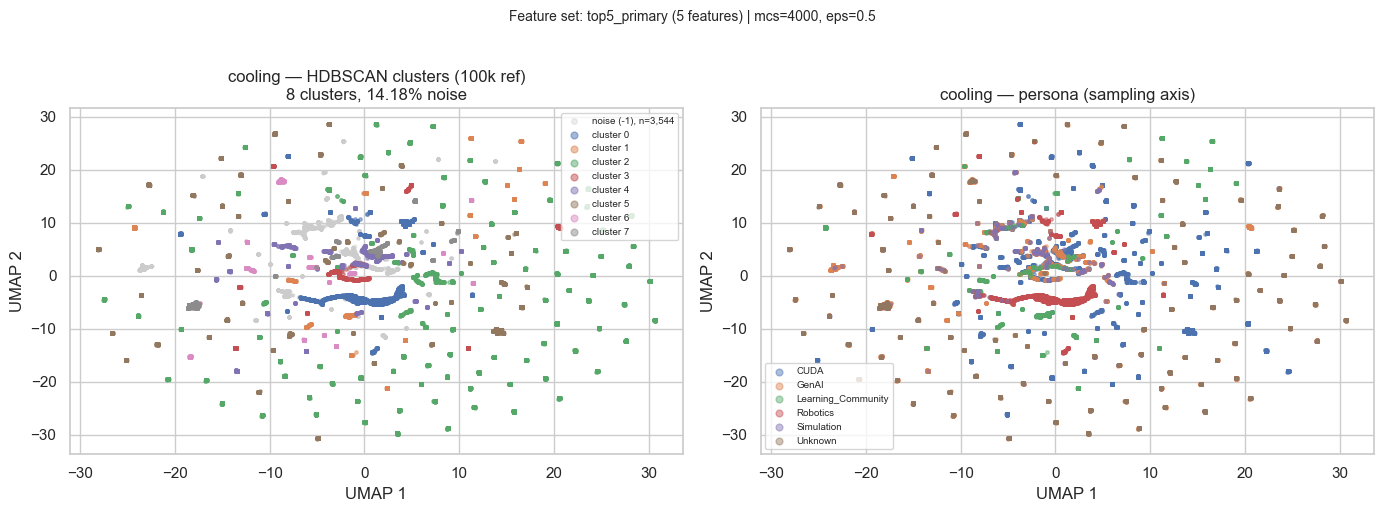

  saved outputs/clustering/final/umap_100k/cooling_100k_clusters_umap.png

dormant: UMAP on 25,000 random subsample of 100,000


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The

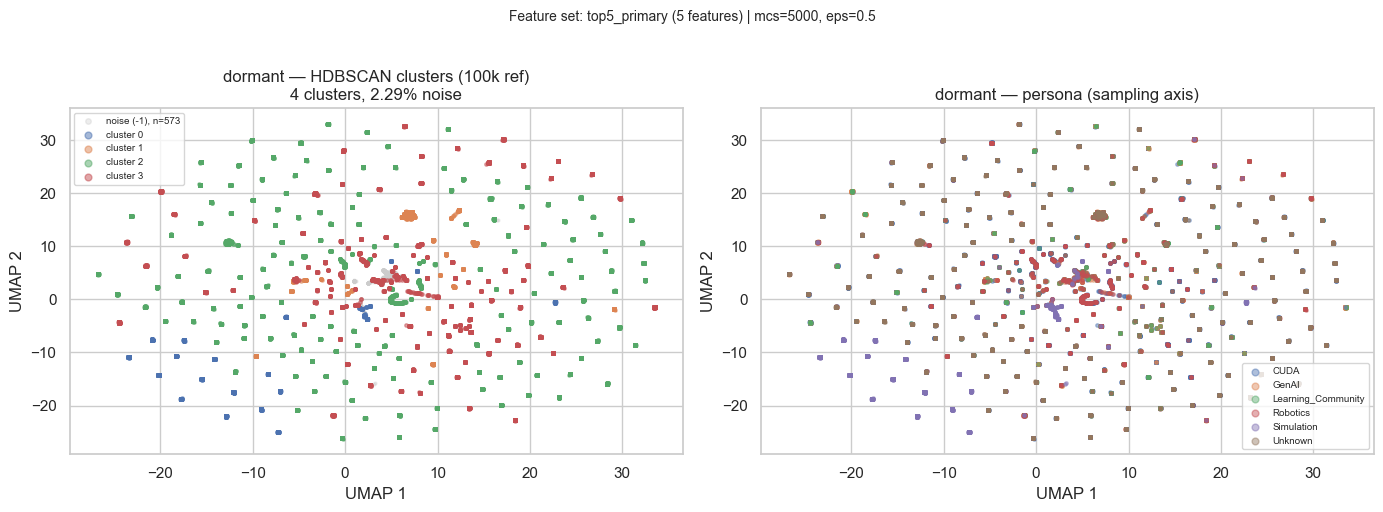

  saved outputs/clustering/final/umap_100k/dormant_100k_clusters_umap.png

UMAP outputs: /Users/pmazolew/Documents/GitHub/Spring2026_IndustryProject/outputs/clustering/final/umap_100k


In [4]:
# UMAP scatter plots for 100k reference HDBSCAN runs (run Section 3 first).

import matplotlib.pyplot as plt
import seaborn as sns

try:
    import umap
except ImportError as e:
    raise ImportError("Install umap-learn: pip install umap-learn") from e

sns.set_theme(style="whitegrid")
UMAP_DIR = OUTPUT_DIR / "umap_100k"
UMAP_DIR.mkdir(parents=True, exist_ok=True)

UMAP_PARAMS = dict(
    n_components=2,
    n_neighbors=30,
    min_dist=0.1,
    metric="euclidean",
    random_state=HASH_SALT,
)

# Subsample for faster UMAP when n > 25k (HDBSCAN labels still from full 100k fit)
UMAP_MAX_POINTS = 25_000

if "REFERENCE" not in globals() or not REFERENCE:
    raise RuntimeError("Run the reference-fit cell (Section 3) first to populate REFERENCE.")

for stratum_key in FINAL_MODELS:
    ref = REFERENCE[stratum_key]
    X = ref["X100"]
    labels = ref["labels"]
    meta = ref["meta_100k"].copy()
    meta["hdbscan_cluster"] = labels
    meta["noise_flag"] = (labels == -1).astype(int)

    n = X.shape[0]
    if n > UMAP_MAX_POINTS:
        rng = np.random.default_rng(HASH_SALT)
        idx = rng.choice(n, size=UMAP_MAX_POINTS, replace=False)
        X_plot = X[idx]
        plot_df = meta.iloc[idx].copy()
        umap_note = f"UMAP on {UMAP_MAX_POINTS:,} random subsample of {n:,}"
    else:
        X_plot = X
        plot_df = meta
        umap_note = f"UMAP on all {n:,} points"

    print(f"\n{stratum_key}: {umap_note}")
    emb = umap.UMAP(**UMAP_PARAMS).fit_transform(X_plot)
    plot_df["umap_x"] = emb[:, 0]
    plot_df["umap_y"] = emb[:, 1]
    plot_df.to_csv(UMAP_DIR / f"{stratum_key}_100k_umap_coords.csv", index=False)

    cluster_ids = sorted(plot_df.loc[plot_df["hdbscan_cluster"] >= 0, "hdbscan_cluster"].unique())
    n_noise = int((plot_df["hdbscan_cluster"] == -1).sum())
    cfg = ref["cfg"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # By HDBSCAN cluster
    noise_mask = plot_df["hdbscan_cluster"] == -1
    if noise_mask.any():
        axes[0].scatter(
            plot_df.loc[noise_mask, "umap_x"],
            plot_df.loc[noise_mask, "umap_y"],
            c="#cccccc", s=4, alpha=0.35, label=f"noise (-1), n={n_noise:,}",
        )
    for cid in cluster_ids:
        m = plot_df["hdbscan_cluster"] == cid
        axes[0].scatter(
            plot_df.loc[m, "umap_x"], plot_df.loc[m, "umap_y"],
            s=6, alpha=0.5, label=f"cluster {int(cid)}",
        )
    noise_pct_plot = round(100.0 * plot_df["noise_flag"].mean(), 2)
    axes[0].set_title(
        f"{stratum_key} — HDBSCAN clusters (100k ref)\n"
        f"{len(cluster_ids)} clusters, {noise_pct_plot}% noise"
    )
    axes[0].set_xlabel("UMAP 1")
    axes[0].set_ylabel("UMAP 2")
    axes[0].legend(markerscale=2, fontsize=7, loc="best")

    # By persona
    for persona in sorted(plot_df["persona"].dropna().unique()):
        m = plot_df["persona"] == persona
        axes[1].scatter(
            plot_df.loc[m, "umap_x"], plot_df.loc[m, "umap_y"],
            s=6, alpha=0.45, label=str(persona),
        )
    axes[1].set_title(f"{stratum_key} — persona (sampling axis)")
    axes[1].set_xlabel("UMAP 1")
    axes[1].set_ylabel("UMAP 2")
    axes[1].legend(markerscale=2, fontsize=7, loc="best")

    fig.suptitle(
        f"Feature set: {cfg['feature_set_type']} ({len(ref['names_kept'])} features) | "
        f"mcs={ref['min_cluster_size']}, eps={cfg['cluster_selection_epsilon']}",
        fontsize=10, y=1.02,
    )
    plt.tight_layout()
    out_png = UMAP_DIR / f"{stratum_key}_100k_clusters_umap.png"
    fig.savefig(out_png, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  saved {out_png}")

print(f"\nUMAP outputs: {UMAP_DIR.resolve()}")

## 4. Cluster full cohort (batched `approximate_predict`)

Assign every developer in each stratum using the model fit on the 100k reference sample. Batched rows are transformed with the **same 100k-fitted** imputer + `RobustScaler`, then `approximate_predict`.


In [5]:

con = duckdb.connect(DB_PATH)
con.execute("SET preserve_insertion_order=false")

all_results = []
full_summary = []

for stratum_key, cfg in FINAL_MODELS.items():
    ref = REFERENCE[stratum_key]
    names = ref["names_kept"]
    clusterer = ref["clusterer"]
    where = cfg["where_sql"]
    feats = cfg["features"]

    cohort_n = cohort_count(con, where)
    print(f"\n{'=' * 60}\n{stratum_key}: assigning cohort_n={cohort_n:,}\n{'=' * 60}")

    out_parts = []
    offset = 0
    total_noise = 0
    total_n = 0
    cluster_counts = {}

    while offset < cohort_n:
        batch = load_cohort_batch(con, where, feats, offset, PREDICT_BATCH_SIZE)
        if batch.empty:
            break
        refd = REFERENCE[stratum_key]
        Xb = transform_preprocessed(
            batch, refd["fit_cols"], refd["preprocessor"], refd["var_keep"]
        )
        labels, _ = hdbscan.approximate_predict(clusterer, Xb)

        batch_out = batch[["developer_id", "persona", "dormancy_status"]].copy()
        batch_out["dormancy_segment"] = stratum_key
        batch_out["hdbscan_cluster"] = labels
        batch_out["noise_flag"] = (labels == -1).astype(int)
        out_parts.append(batch_out)

        total_n += len(labels)
        total_noise += (labels == -1).sum()
        for cid in labels:
            cluster_counts[int(cid)] = cluster_counts.get(int(cid), 0) + 1

        offset += len(batch)
        if offset % 200_000 == 0 or offset >= cohort_n:
            print(f"  processed {min(offset, cohort_n):,} / {cohort_n:,}")

    stratum_results = pd.concat(out_parts, ignore_index=True)
    stratum_dir = OUTPUT_DIR / stratum_key
    stratum_dir.mkdir(parents=True, exist_ok=True)
    stratum_results.to_parquet(stratum_dir / "cluster_results_full.parquet", index=False)

    noise_pct = round(100.0 * total_noise / total_n, 2)
    n_clusters = len([c for c in cluster_counts if c >= 0])
    full_summary.append({
        "stratum": stratum_key,
        "feature_set_type": cfg["feature_set_type"],
        "n_features_used": len(names),
        "cohort_n": cohort_n,
        "assigned_n": total_n,
        "n_clusters": n_clusters,
        "noise_pct_full": noise_pct,
        "noise_pct_100k_ref": ref_df.loc[ref_df.stratum == stratum_key, "noise_pct"].iloc[0],
        "min_cluster_size": ref["min_cluster_size"],
        "cluster_selection_epsilon": cfg["cluster_selection_epsilon"],
        "min_samples": cfg["min_samples"],
    })

    joblib.dump(
        {
            "preprocessor": ref["preprocessor"],
            "fit_cols": ref["fit_cols"],
            "feature_names": names,
            "var_keep": ref["var_keep"],
            "clusterer": clusterer,
            "config": cfg,
            "reference_100k": ref_df.loc[ref_df.stratum == stratum_key].to_dict(),
        },
        stratum_dir / "model.joblib",
    )
    pd.Series(names, name="feature").to_csv(stratum_dir / "features_used.csv", index=False)

    all_results.append(stratum_results)

con.close()

combined = pd.concat(all_results, ignore_index=True)
combined.to_parquet(OUTPUT_DIR / "cluster_results_all_strata.parquet", index=False)

summary_df = pd.DataFrame(full_summary)
summary_df.to_csv(OUTPUT_DIR / "full_cohort_summary.csv", index=False)

print(f"\nSaved: {OUTPUT_DIR.resolve()}")
display(summary_df)
display(combined.groupby(["dormancy_segment", "hdbscan_cluster"]).size().head(20))



active: assigning cohort_n=418,049
  processed 200,000 / 418,049
  processed 400,000 / 418,049
  processed 418,049 / 418,049

cooling: assigning cohort_n=356,500
  processed 200,000 / 356,500
  processed 356,500 / 356,500

dormant: assigning cohort_n=5,304,852
  processed 200,000 / 5,304,852
  processed 400,000 / 5,304,852
  processed 600,000 / 5,304,852
  processed 800,000 / 5,304,852
  processed 1,000,000 / 5,304,852
  processed 1,200,000 / 5,304,852
  processed 1,400,000 / 5,304,852
  processed 1,600,000 / 5,304,852
  processed 1,800,000 / 5,304,852
  processed 2,000,000 / 5,304,852
  processed 2,200,000 / 5,304,852
  processed 2,400,000 / 5,304,852
  processed 2,600,000 / 5,304,852
  processed 2,800,000 / 5,304,852
  processed 3,000,000 / 5,304,852
  processed 3,200,000 / 5,304,852
  processed 3,400,000 / 5,304,852
  processed 3,600,000 / 5,304,852
  processed 3,800,000 / 5,304,852
  processed 4,000,000 / 5,304,852
  processed 4,200,000 / 5,304,852
  processed 4,400,000 / 5,304,85

,stratum,feature_set_type,n_features_used,cohort_n,assigned_n,n_clusters,noise_pct_full,noise_pct_100k_ref,min_cluster_size,cluster_selection_epsilon,min_samples
0,active,full_16,16,418049,418049,6,5.79,5.80,499,0.75,15
1,cooling,top5_primary,5,356500,356500,8,14.25,14.06,4000,0.50,10
2,dormant,top5_primary,5,5304852,5304852,4,2.47,2.43,5000,0.50,25


dormancy_segment  hdbscan_cluster
active            -1                   24187
                   0                    2624
                   1                   47486
                   2                    2970
                   3                   17966
                   4                    2857
                   5                  319959
cooling           -1                   50810
                   0                   38887
                   1                   15854
                   2                  131497
                   3                   16641
                   4                   17942
                   5                   52109
                   6                   16513
                   7                   16247
dormant           -1                  130934
                   0                  395691
                   1                  475314
                   2                 2709988
dtype: int64

## 5. Quick validation (full cohort labels)

Compare 100k reference metrics to full-cohort assignment noise and show largest cluster shares.


In [6]:

val_rows = []
for stratum_key in FINAL_MODELS:
    path = OUTPUT_DIR / stratum_key / "cluster_results_full.parquet"
    df = pd.read_parquet(path)
    sizes = df["hdbscan_cluster"].value_counts()
    largest = sizes.max()
    val_rows.append({
        "stratum": stratum_key,
        "n": len(df),
        "n_clusters": df.loc[df["hdbscan_cluster"] >= 0, "hdbscan_cluster"].nunique(),
        "noise_pct": round(100 * (df["hdbscan_cluster"] == -1).mean(), 2),
        "largest_cluster_pct": round(100 * largest / len(df), 2),
        "largest_cluster_id": int(sizes.idxmax()),
    })

val_df = pd.DataFrame(val_rows)
val_df = val_df.merge(ref_df[["stratum", "noise_pct", "n_clusters"]], on="stratum", suffixes=("_full", "_100k"))
val_df.to_csv(OUTPUT_DIR / "validation_full_vs_100k.csv", index=False)
display(val_df)

for sk in FINAL_MODELS:
    df = pd.read_parquet(OUTPUT_DIR / sk / "cluster_results_full.parquet")
    print(f"\n--- {sk}: persona vs cluster ---")
    display(pd.crosstab(df["persona"], df["hdbscan_cluster"], normalize="columns").round(2))


,stratum,n,n_clusters_full,noise_pct_full,largest_cluster_pct,largest_cluster_id,noise_pct_100k,n_clusters_100k
0,active,418049,6,5.79,76.54,5,5.80,6
1,cooling,356500,8,14.25,36.89,2,14.06,8
2,dormant,5304852,4,2.47,51.09,2,2.43,4



--- active: persona vs cluster ---


hdbscan_cluster,-1,0,1,2,3,4,5
persona,,,,,,,
CUDA,0.22,0.16,0.24,0.13,0.15,0.41,0.12
GenAI,0.41,0.70,0.66,0.50,0.44,0.16,0.75
Learning_Community,0.08,0.03,0.04,0.19,0.25,0.14,0.00
Robotics,0.24,0.09,0.06,0.14,0.12,0.09,0.04
Simulation,0.06,0.02,0.00,0.04,0.02,0.04,0.02
Unknown,0.01,0.00,0.00,0.00,0.01,0.16,0.07



--- cooling: persona vs cluster ---


hdbscan_cluster,-1,0,1,2,3,4,5,6,7
persona,,,,,,,,,
CUDA,0.33,0.02,0.0,0.29,0.35,0.50,0.42,0.12,0.44
GenAI,0.44,0.19,0.0,0.51,0.59,0.40,0.40,0.79,0.43
Learning_Community,0.14,0.00,1.0,0.00,0.05,0.09,0.00,0.00,0.00
Robotics,0.05,0.79,0.0,0.00,0.00,0.00,0.00,0.00,0.00
Simulation,0.03,0.00,0.0,0.04,0.01,0.01,0.07,0.03,0.04
Unknown,0.00,0.00,0.0,0.16,0.00,0.00,0.11,0.06,0.08



--- dormant: persona vs cluster ---


hdbscan_cluster,-1,0,1,2,3
persona,,,,,
CUDA,0.40,0.0,0.14,0.64,0.55
GenAI,0.21,0.0,0.46,0.10,0.31
Learning_Community,0.13,0.0,0.26,0.02,0.08
Robotics,0.11,0.0,0.12,0.07,0.05
Simulation,0.15,1.0,0.00,0.00,0.00
Unknown,0.01,0.0,0.02,0.16,0.00
